In [57]:
from typing import  TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [58]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [64]:
def greeting_node(state: AgentState) -> AgentState:
    """
    The function greets the user.
    """

    state['name'] = f"Hi there {state['name'] } !"
    state['counter'] = 0

    return state



def rundom_node(state: AgentState)-> AgentState:
    """
    The function generates numbers from 0 to 10.
    """

    state['number'].append(random.randint(0, 10))
    state['counter'] +=1

    return state

def should_continue(state: AgentState)-> AgentState:

    """
    The function makes desicion what to do next
    """

    if state['counter'] < 5:
        print('ENNTERING LOOP', state['counter'] )
        return 'loop'
    else:
        return 'end'

In [65]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", rundom_node)

graph.add_edge("greeting", "random")
graph.add_conditional_edges("random", should_continue, {"loop": "random", "end": END})
graph.set_entry_point("greeting")

app = graph.compile()


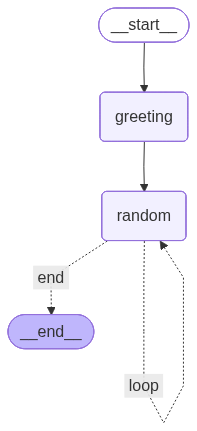

In [66]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [67]:
app.invoke({'name': 'roman', 'number': [], 'counter': -1})

ENNTERING LOOP 1
ENNTERING LOOP 2
ENNTERING LOOP 3
ENNTERING LOOP 4


{'name': 'Hi there roman !', 'number': [3, 8, 10, 0, 8], 'counter': 5}